In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("Custom_Crops_yield_Historical_Dataset.csv")

## Analyze relationships between features

### Subtask:
Use scatter plots, correlation matrices, or other relevant visualizations to explore relationships between different features.

**Reasoning**:
Calculate the correlation matrix for numerical columns and create a heatmap to visualize the correlations.

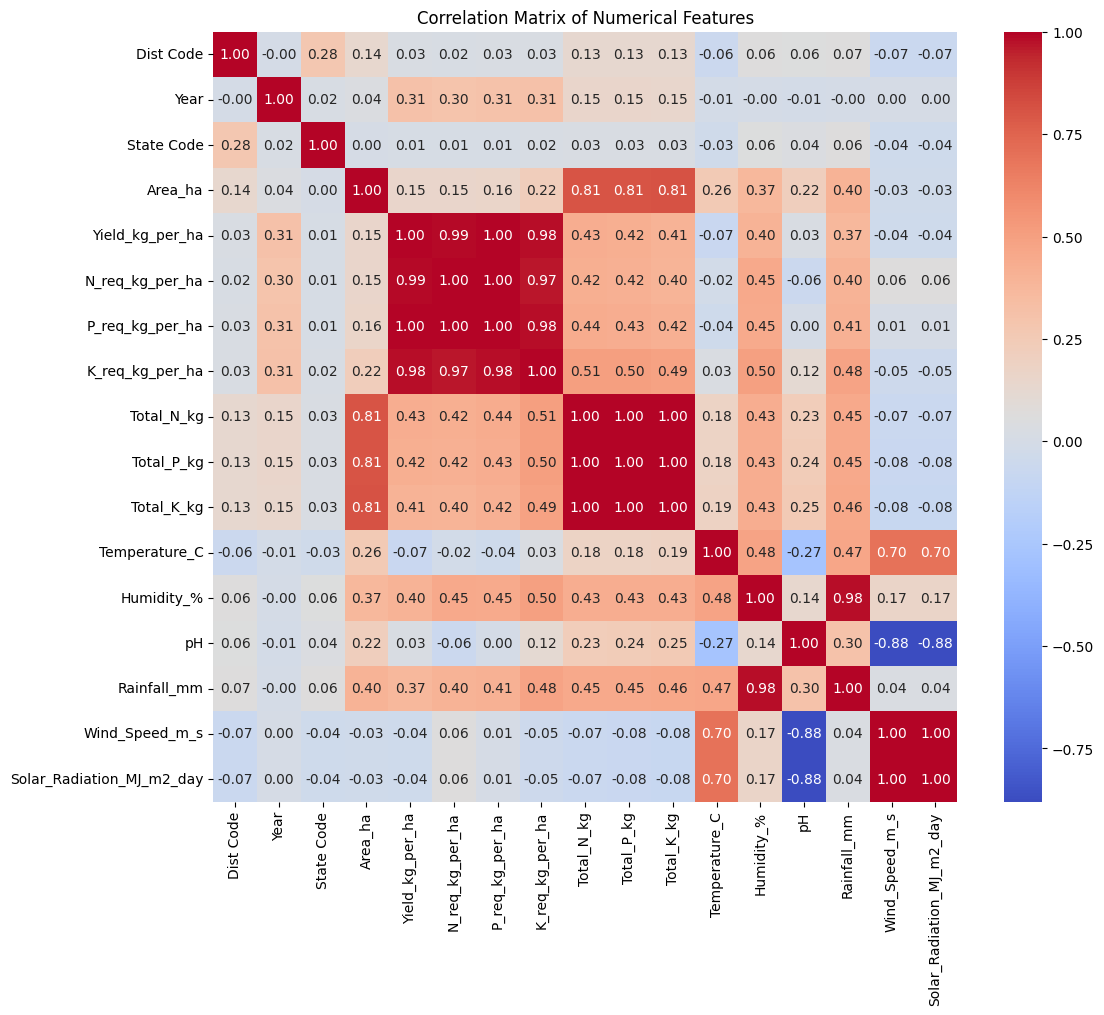

In [21]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [22]:
df.columns

Index(['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop',
       'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha',
       'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg',
       'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s',
       'Solar_Radiation_MJ_m2_day'],
      dtype='object')

**Reasoning**:
Drop the columns as requested by the user based on domain knowledge and correlation analysis.

In [5]:
columns_to_drop = [

    'Dist Code', 'Year', 'State Code',
    'Solar_Radiation_MJ_m2_day',
    'Total_N_kg', 'Total_P_kg', 'Total_K_kg',
    "N_req_kg_per_ha" , 
  "P_req_kg_per_ha",
  "K_req_kg_per_ha",
    'Wind_Speed_m_s'
]

df = df.drop(columns=columns_to_drop)

display(df.head())
display(df.info())

,State Name,Dist Name,Crop,Area_ha,Yield_kg_per_ha,Temperature_C,Humidity_%,pH,Rainfall_mm
0,Chhattisgarh,Durg,rice,548000.0,337.59,25,80,6.5,1200
1,Chhattisgarh,Durg,maize,3000.0,666.67,22,70,6.0,800
2,Chhattisgarh,Durg,chickpea,54000.0,500.00,20,60,6.5,600
3,Chhattisgarh,Durg,rice,547000.0,747.71,25,80,6.5,1200
4,Chhattisgarh,Durg,maize,3000.0,1000.00,22,70,6.0,800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50765 entries, 0 to 50764
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State Name       50765 non-null  object 
 1   Dist Name        50765 non-null  object 
 2   Crop             50765 non-null  object 
 3   Area_ha          50765 non-null  float64
 4   Yield_kg_per_ha  50765 non-null  float64
 5   Temperature_C    50765 non-null  int64  
 6   Humidity_%       50765 non-null  int64  
 7   pH               50765 non-null  float64
 8   Rainfall_mm      50765 non-null  int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 3.5+ MB


None

In [25]:
df.columns

Index(['State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha',
       'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm'],
      dtype='object')

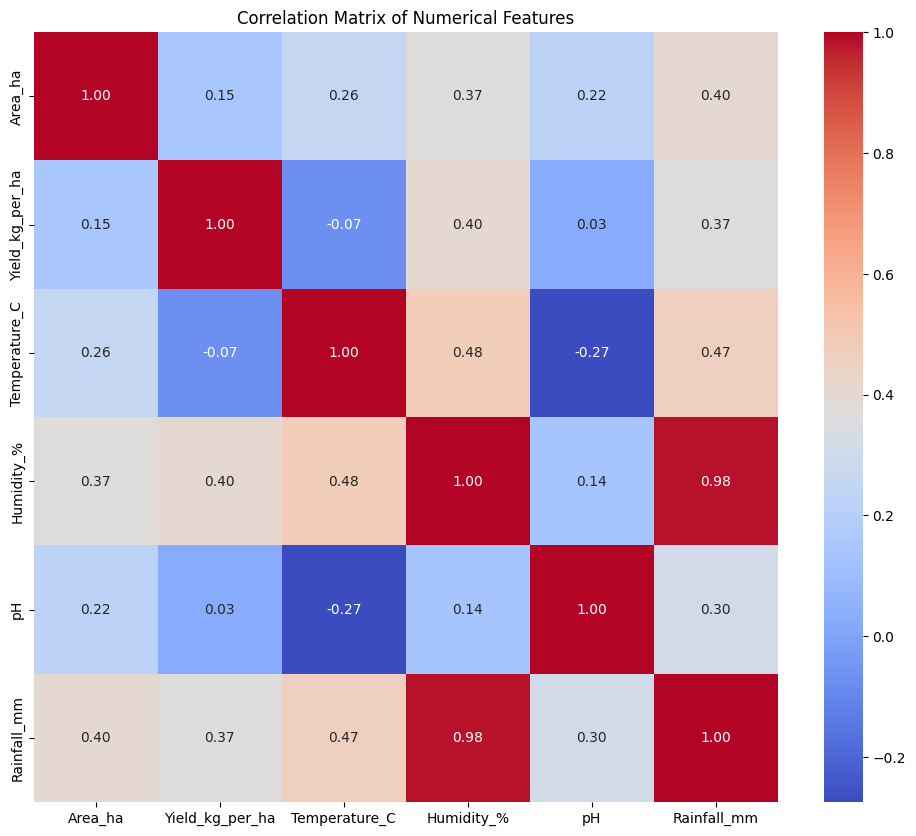

In [26]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Prepare data for modeling

### Subtask:
Handle categorical features (e.g., one-hot encoding) and split the data into training and testing sets.

**Reasoning**:
Apply one-hot encoding to the categorical features and then split the data into training and testing sets for model training and evaluation.

In [6]:
from sklearn.model_selection import train_test_split

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['bool', 'object']).columns

# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('Yield_kg_per_ha', axis=1)
y = df_encoded['Yield_kg_per_ha']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (40612, 337)
Shape of X_test: (10153, 337)
Shape of y_train: (40612,)
Shape of y_test: (10153,)


In [28]:
X_train.columns

Index(['Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm',
       'State Name_Assam', 'State Name_Bihar', 'State Name_Chhattisgarh',
       'State Name_Gujarat', 'State Name_Haryana',
       ...
       'Dist Name_Vidisha', 'Dist Name_Visakhapatnam', 'Dist Name_Warangal',
       'Dist Name_Wardha', 'Dist Name_West Dinajpur',
       'Dist Name_West Godavari', 'Dist Name_Yeotmal', 'Crop_cotton',
       'Crop_maize', 'Crop_rice'],
      dtype='object', length=337)

In [29]:
X_train.head()

,Area_ha,Temperature_C,Humidity_%,pH,Rainfall_mm,State Name_Assam,State Name_Bihar,State Name_Chhattisgarh,State Name_Gujarat,State Name_Haryana,...,Dist Name_Vidisha,Dist Name_Visakhapatnam,Dist Name_Warangal,Dist Name_Wardha,Dist Name_West Dinajpur,Dist Name_West Godavari,Dist Name_Yeotmal,Crop_cotton,Crop_maize,Crop_rice
33299,400.0,28,65,6.0,700,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
911,362000.0,25,80,6.5,1200,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2772,1300.0,22,70,6.0,800,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
41078,126390.0,25,80,6.5,1200,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2351,30000.0,25,80,6.5,1200,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [7]:
X_train.columns

Index(['Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm',
       'State Name_Assam', 'State Name_Bihar', 'State Name_Chhattisgarh',
       'State Name_Gujarat', 'State Name_Haryana',
       ...
       'Dist Name_Vidisha', 'Dist Name_Visakhapatnam', 'Dist Name_Warangal',
       'Dist Name_Wardha', 'Dist Name_West Dinajpur',
       'Dist Name_West Godavari', 'Dist Name_Yeotmal', 'Crop_cotton',
       'Crop_maize', 'Crop_rice'],
      dtype='object', length=337)

# Task
Train multiple models for yield prediction using cross-validation and hyperparameter tuning, evaluate their performance, and select the best model.

## Choose multiple models

### Subtask:
Select a few suitable machine learning models for regression (e.g., Linear Regression, Random Forest, Gradient Boosting).


**Reasoning**:
Import the required regression models from scikit-learn to prepare for model training.



In [31]:

from sklearn.ensemble import GradientBoostingRegressor

# training using GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train, y_train)
y_pred_gb = gradient_boosting_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting Regressor - MSE: {mse_gb}, R²: {r2_gb}")


Gradient Boosting Regressor - MSE: 409702.87453061814, R²: 0.5569553403257175


In [ ]:
# do gridsearch cv on gradient boosting regressor to find best hyperparameters
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=3,verbose=2, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

best_gb_model = grid_search.best_estimator_
y_pred_best_gb = best_gb_model.predict(X_test)
mse_best_gb = mean_squared_error(y_test, y_pred_best_gb)
r2_best_gb = r2_score(y_test, y_pred_best_gb)
print(f"Best Gradient Boosting Regressor - MSE: {mse_best_gb}, R²: {r2_best_gb}")


# save the best model using pkl
import pickle
with open('best_gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(best_gb_model, f)




Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Gradient Boosting Regressor - MSE: 375343.5646220643, R²: 0.5941108247301619


In [33]:
import pickle
with open('best_gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(best_gb_model, f)


In [30]:
# Ridge Regression (L2 Regularization)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression - MSE: {mse_ridge:.2f}, R²: {r2_ridge:.2f}")

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso Regression - MSE: {mse_lasso:.2f}, R²: {r2_lasso:.2f}")

# ElasticNet
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)
print(f"ElasticNet - MSE: {mse_elastic:.2f}, R²: {r2_elastic:.2f}")

# Simplified Random Forest (reduce overfitting)
from sklearn.ensemble import RandomForestRegressor
rf_simple = RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_split=10, random_state=42)
rf_simple.fit(X_train, y_train)
y_pred_rf_simple = rf_simple.predict(X_test)
mse_rf_simple = mean_squared_error(y_test, y_pred_rf_simple)
r2_rf_simple = r2_score(y_test, y_pred_rf_simple)
print(f"Simplified Random Forest - MSE: {mse_rf_simple:.2f}, R²: {r2_rf_simple:.2f}")

Ridge Regression - MSE: 493107.23, R²: 0.47
Lasso Regression - MSE: 493254.75, R²: 0.47
Lasso Regression - MSE: 493254.75, R²: 0.47
ElasticNet - MSE: 550623.23, R²: 0.40
ElasticNet - MSE: 550623.23, R²: 0.40
Simplified Random Forest - MSE: 489496.56, R²: 0.47
Simplified Random Forest - MSE: 489496.56, R²: 0.47


## Addressing Overfitting: Regularization and Model Simplification

To reduce overfitting, you can use regularized models and/or reduce model complexity:



- **Linear Models:** Use Ridge Regression (L2), Lasso Regression (L1), or ElasticNet.

- **Tree-based Models:** Reduce `max_depth`, increase `min_samples_split`, or use fewer estimators.

- **Feature Selection:** Limit the number of features using feature importance or other selection methods.

- **Pruning Trees:** Use shallower trees or pruning techniques.



Below are examples for Ridge, Lasso, and simplified Random Forest.

In [15]:
# show some predictions with real values
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Ridge_Predicted': y_pred_ridge,
    'Lasso_Predicted': y_pred_lasso,
    'ElasticNet_Predicted': y_pred_elastic,
    'RF_Simple_Predicted': y_pred_rf_simple
})

In [16]:
predictions_df.head(10)

,Actual,Ridge_Predicted,Lasso_Predicted,ElasticNet_Predicted,RF_Simple_Predicted
17795,2157.01,2171.742532,2180.293452,2184.724852,2156.137430
42737,90.91,100.313447,133.217209,141.575304,83.984422
41746,2030.45,2033.371627,2043.932569,2045.750954,2045.358519
3863,461.54,448.376036,429.355537,420.314310,522.873404
14222,1542.37,1536.509233,1530.400300,1532.320254,1568.291118
4985,3272.85,3264.373007,3278.011508,3271.552395,3279.860248
21126,1988.89,1985.244021,1988.740556,1987.725879,1994.351365
4613,529.27,529.725701,548.570511,550.656939,498.364887
11900,250.00,249.248276,272.785779,282.209291,250.021276
39265,1698.41,1691.671657,1698.339369,1697.136264,1757.374824


In [8]:
# Load the saved model to examine its features
import pickle
with open('best_gradient_boosting_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("Model type:", type(loaded_model))
print("Number of features expected:", loaded_model.n_features_in_)
print("Feature names (first 10):", X_train.columns[:10].tolist())
print("Total features:", len(X_train.columns))

Model type: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
Number of features expected: 337
Feature names (first 10): ['Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'State Name_Assam', 'State Name_Bihar', 'State Name_Chhattisgarh', 'State Name_Gujarat', 'State Name_Haryana']
Total features: 337


In [9]:
# Get unique values for categorical features
print("Unique States:", df['State Name'].unique())
print("\nNumber of unique states:", len(df['State Name'].unique()))
print("\nUnique Crops:", df['Crop'].unique())
print("\nNumber of unique districts:", len(df['Dist Name'].unique()))

Unique States: ['Chhattisgarh' 'Madhya Pradesh' 'Andhra Pradesh' 'Telangana' 'Karnataka'
 'Tamil Nadu' 'Maharashtra' 'Gujarat' 'Rajasthan' 'Punjab' 'Haryana'
 'Uttar Pradesh' 'Uttarakhand' 'Assam' 'Himachal Pradesh' 'Kerala'
 'Orissa' 'West Bengal' 'Bihar' 'Jharkhand']

Number of unique states: 20

Unique Crops: ['rice' 'maize' 'chickpea' 'cotton']

Number of unique districts: 311
